In [1]:
from lgdo.lh5 import LH5Store, ls, show, load_dfs

from dspeed.vis import WaveformBrowser
from dspeed import units
from dspeed import build_dsp
import numpy as np
import pandas as pd


from scipy import stats


import matplotlib.pyplot as plt
import os , json


import pint
u = pint.get_application_registry()


import os

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["font.size"] = 12



In [2]:

df_summary_25_P08 = pd.read_pickle("PRL_Processed/df_summary_PRL_25_showers.pkl")


df_summary_15_P08 = pd.read_pickle("PRL_Processed/df_summary_PRL_15_showers.pkl")


df_summary_muon_P08 = pd.read_pickle("PRL_Processed/df_summary_PRL_MUON.pkl")


detector_locations = pd.read_excel("L200_Det_Radii_Pos.xlsx")


#This just extracts the columns so I can pull this information later 

location_lookup = detector_locations.set_index("Detector_ID")[["X (mm)", "Y (mm)", "Z (mm)"]]



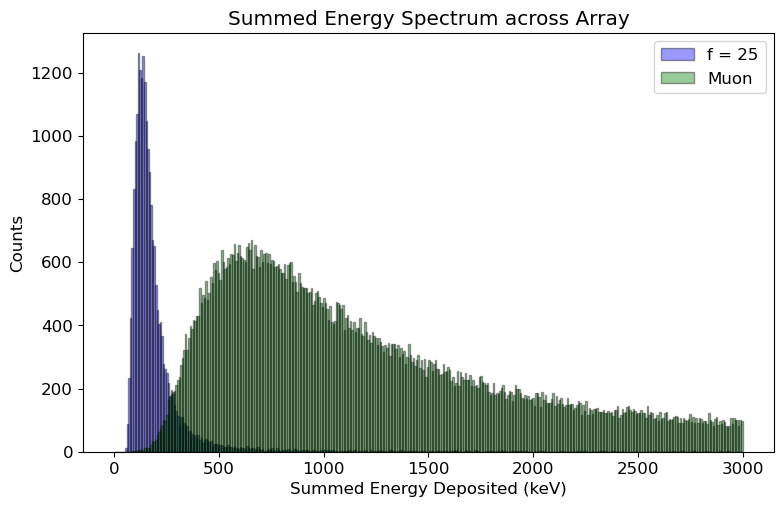

In [3]:
passed_multi_FCP_1 = df_summary_25_P08[df_summary_25_P08["multiplicity"] > 2]

passed_multi_FCP_2 = passed_multi_FCP_1[passed_multi_FCP_1["multiplicity"] < 7]

summed_edep_FCP = passed_multi_FCP_2.groupby("evtid")["total_edep"].sum()


passed_multi_MUON_1 = df_summary_muon_P08[df_summary_muon_P08["multiplicity"] > 2]

passed_multi_MUON_2 = passed_multi_MUON_1[passed_multi_MUON_1["multiplicity"] < 7]

summed_edep_MUON = passed_multi_MUON_2.groupby("evtid")["total_edep"].sum()


import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

plt.figure(figsize=(8,5))

xmin = 0
xmax = 3000   # set whatever range you want

plt.hist(
    summed_edep_FCP,
    bins=400,
    range=(xmin, xmax),
    color='b',
    alpha=0.4,
    label="f = 25",
    edgecolor='black'
)

plt.hist(
    summed_edep_MUON,
    bins=400,
    range=(xmin, xmax),
    color='g',
    alpha=0.4,
    label="Muon",
    edgecolor='black'
)

plt.xlabel("Summed Energy Deposited (keV)")
plt.ylabel("Counts")

# turn off scientific notation
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

plt.legend()
plt.tight_layout()
plt.title("Summed Energy Spectrum across Array")
plt.show()


In [4]:
std_devs_25 = pd.read_pickle("std_devs_25.pkl")

std_devs_15 = pd.read_pickle("std_devs_15.pkl")

std_devs_muon = pd.read_pickle("std_devs_MUON.pkl")


std_devs_muon

,evtid,weighted_std_dev_cos_theta,weighted_std_dev_phi
0,381,0.235457,0.827400
1,481,0.411155,1.081452
2,484,0.409554,1.597721
3,549,0.298747,1.104985
4,555,0.124939,0.621282
...,...,...,...
553209,99998630,0.417725,1.433334
553210,99998898,0.237471,1.196998
553211,99998931,0.229986,1.334963
553212,99999655,0.288486,0.373972


In [5]:
import numpy as np
import pandas as pd
from itertools import product
from scipy.interpolate import interp1d   


def prepare_fc_lookup(fc_x, fc_y):
    """
    Prepare an interpolator that returns fc_n for any (possibly non-integer) mu_b.
    fc_x: array-like of mu_b points (expected background mean; typically integers 0,1,2,...)
    fc_y: array-like of corresponding Feldman-Cousins n values at those mu_b points
    Returns: function fc_interp(mu) -> n (float)
    """
    fc_x = np.asarray(fc_x)
    fc_y = np.asarray(fc_y)
    # sort just in case
    order = np.argsort(fc_x)
    fc_x = fc_x[order]
    fc_y = fc_y[order]
    # create linear interpolator with fill_value="extrapolate" (or you can clamp)
    interp = interp1d(fc_x, fc_y, kind='linear', bounds_error=False, fill_value=(fc_y[0], fc_y[-1]))
    return interp


def apply_all_cuts(df, std_devs, phi_cut, cos_cut, energy_max, multi_upper):
    """
    Applies all cuts (including variable multiplicity upper limit)
    and returns surviving fraction (efficiency).
    """
    df_trigger = df[df["multiplicity"] > 2]
    total = df_trigger["evtid"].nunique()

    #Multi Cut
    df_mult = df_trigger[df_trigger["multiplicity"] < multi_upper]

    #Energy Cut
    summed = df_mult.groupby("evtid")["total_edep"].sum()
    passed_energy = summed[summed < energy_max]
    df_energy = df_mult[df_mult["evtid"].isin(passed_energy.index)]

    #Spatial Cut
    std_cut = std_devs[std_devs["evtid"].isin(df_energy["evtid"])]
    spatial_passed = std_cut[
        (std_cut["weighted_std_dev_phi"] < phi_cut) &
        (std_cut["weighted_std_dev_cos_theta"] < cos_cut)
    ]

    df_final = df_energy[df_energy["evtid"].isin(spatial_passed["evtid"])]

    eff = df_final["evtid"].nunique() / total if total > 0 else 0.0
    return eff

#This is the grid search range and spacing, it takes a long time so this needs adjusting depending on how precise you want it 


#energy_grid = np.linspace(170, 200, 10)
#phi_grid = np.linspace(2.00, 2.5, 10)
#cos_grid = np.linspace(0.4, 0.5, 10)
#multi_upper_grid = np.arange(7, 9, 1)    

energy_grid = np.linspace(100, 350 , 10)
phi_grid = np.linspace(0.1, 3.5, 5)
cos_grid = np.linspace(0.1, 1.5, 10)
multi_upper_grid = np.arange(7, 12, 1) 

results = []

#This matches the number of background signals to the feldman-cousins constant
fc_dict = {
    0: 2.44,
    1: 3.36,
    2: 3.91,
    3: 4.42,
    4: 4.6,
    5: 4.99,
    6: 5.47,
    7: 5.53,
    8: 5.99,
    9: 6.3,
    10: 6.5,
    11: 6.81,
    12: 7,
    13: 7.05,
    14: 7.5,
    15: 7.52 
    
}

fc_x = np.array(list(fc_dict.keys()), dtype=float)
fc_y = np.array(list(fc_dict.values()), dtype=float)
fc_interp = prepare_fc_lookup(fc_x, fc_y)



for energy_max, phi_cut, cos_cut, multi_upper in product(energy_grid, phi_grid, cos_grid, multi_upper_grid):
    eff_b = apply_all_cuts(df_summary_muon_P08[df_summary_muon_P08["multiplicity"] > 2], std_devs_muon, phi_cut, cos_cut, energy_max, multi_upper)
    eff_s = apply_all_cuts(df_summary_25_P08[df_summary_25_P08["multiplicity"] > 2], std_devs_25, phi_cut, cos_cut, energy_max, multi_upper)
    #this calculates the figure of merit
    fom = eff_s / np.sqrt(eff_b) if eff_b > 0 else 0.0

    # compute expected background mean mu_b from epsilon_bkg
    mu_b = eff_b * (2878.0 * 2.93)

    # get Feldman-Cousins n 
    fc_n = float(fc_interp(mu_b))

    results.append({
        "energy_max": energy_max,
        "phi_cut": phi_cut,
        "cos_cut": cos_cut,
        "multi_upper": multi_upper,
        "eff_signal": eff_s,
        "eff_bkg": eff_b,
        "FoM": fom,
        "mu_b": mu_b,
        "fc_n": fc_n
    })


df_fom = pd.DataFrame(results)

bkg_max = 15 / (2878.0 * 2.93)   # 0.00521


valid = df_fom[df_fom["eff_bkg"] < bkg_max].copy()

if valid.empty:
    print(f"No cut combination satisfies eff_bkg < {bkg_max}")
else:
    # scoring: minimize Feldman-Cousins n / signal efficiency
    valid["score"] = valid["fc_n"] / (valid["eff_signal"])
    valid["logscore"] = np.log(valid["fc_n"]) - np.log(valid["eff_signal"])

    best_log = valid.loc[valid["logscore"].idxmin()]

    print("Best cut under eff_bkg < bkg_max:")
    print(best_log[[
        "energy_max","phi_cut","cos_cut","multi_upper",
        "eff_signal","eff_bkg","FoM","mu_b","fc_n","logscore"
    ]])



Best cut under eff_bkg < bkg_max:
energy_max     183.333333
phi_cut          2.650000
cos_cut          0.411111
multi_upper      7.000000
eff_signal       0.652703
eff_bkg          0.000164
FoM             50.891070
mu_b             1.387096
fc_n             3.572903
logscore         1.700011
Name: 910, dtype: float64


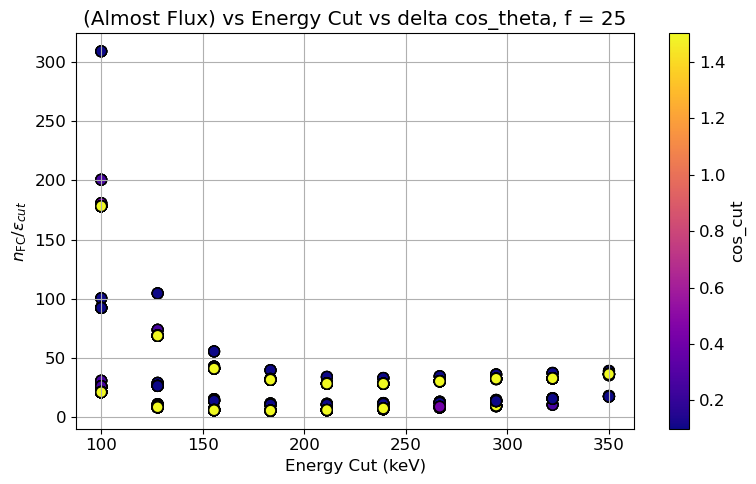

In [6]:
import matplotlib.pyplot as plt

# Filter points under background constraint
df_plot = df_fom[df_fom["eff_bkg"] < bkg_max].copy()
df_plot["score"] = df_plot["fc_n"] / (df_plot["eff_signal"] + 1e-12)  # compute score

plt.figure(figsize=(8,5))
scatter = plt.scatter(
    df_plot["energy_max"],   # x-axis
    df_plot["score"],        # y-axis
    c=df_plot["cos_cut"],    # color by cos_cut
    s=60,
    cmap="plasma",
    edgecolor='k'
)

cbar = plt.colorbar(scatter)
cbar.set_label("cos_cut")

plt.xlabel("Energy Cut (keV)")
plt.ylabel(r"$n_{\rm FC} / \epsilon_{cut}$")
plt.title("(Almost Flux) vs Energy Cut vs delta cos_theta, f = 25")
plt.grid(True)
plt.tight_layout()
plt.show()



#recreate this plot, with two different plots, one holding cos(theta), and phi cut still. The color will be the optimization parameter. 
#the other one hold multiplicity and energy still, and make a plot for the angular cuts. 




Best cut under eff_bkg < bkg_max:
energy_max     176.000000
phi_cut          1.555556
cos_cut          0.422222
multi_upper      7.000000
eff_signal       0.615681
eff_bkg          0.000114
FoM             57.694226
mu_b             0.960297
fc_n             3.323474
logscore         1.686036
Name: 21, dtype: float64


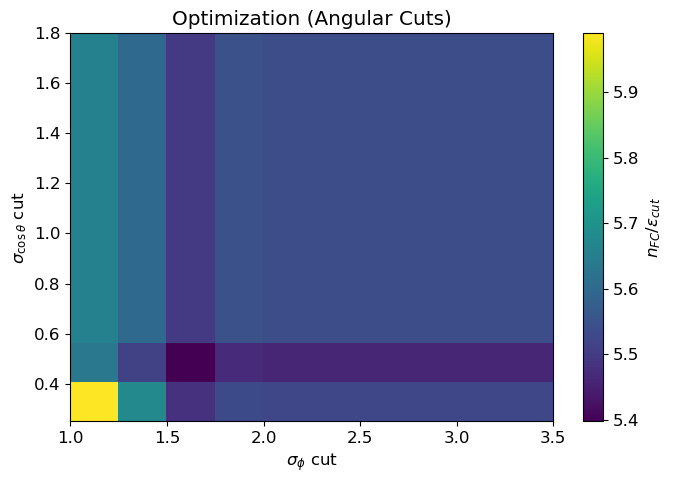

In [8]:
import numpy as np
import pandas as pd
from itertools import product
from scipy.interpolate import interp1d   


def prepare_fc_lookup(fc_x, fc_y):
    """
    Prepare an interpolator that returns fc_n for any (possibly non-integer) mu_b.
    fc_x: array-like of mu_b points (expected background mean; typically integers 0,1,2,...)
    fc_y: array-like of corresponding Feldman-Cousins n values at those mu_b points
    Returns: function fc_interp(mu) -> n (float)
    """
    fc_x = np.asarray(fc_x)
    fc_y = np.asarray(fc_y)
    # sort just in case
    order = np.argsort(fc_x)
    fc_x = fc_x[order]
    fc_y = fc_y[order]
    # create linear interpolator with fill_value="extrapolate" (or you can clamp)
    interp = interp1d(fc_x, fc_y, kind='linear', bounds_error=False, fill_value=(fc_y[0], fc_y[-1]))
    return interp


def apply_all_cuts(df, std_devs, phi_cut, cos_cut, energy_max, multi_upper):
    """
    Applies all cuts (including variable multiplicity upper limit)
    and returns surviving fraction (efficiency).
    """
    df_trigger = df[df["multiplicity"] > 2]
    total = df_trigger["evtid"].nunique()

    #Multi Cut
    df_mult = df_trigger[df_trigger["multiplicity"] < multi_upper]

    #Energy Cut
    summed = df_mult.groupby("evtid")["total_edep"].sum()
    passed_energy = summed[summed < energy_max]
    df_energy = df_mult[df_mult["evtid"].isin(passed_energy.index)]

    #Spatial Cut
    std_cut = std_devs[std_devs["evtid"].isin(df_energy["evtid"])]
    spatial_passed = std_cut[
        (std_cut["weighted_std_dev_phi"] < phi_cut) &
        (std_cut["weighted_std_dev_cos_theta"] < cos_cut)
    ]

    df_final = df_energy[df_energy["evtid"].isin(spatial_passed["evtid"])]

    eff = df_final["evtid"].nunique() / total if total > 0 else 0.0
    return eff

   

energy_grid = [176]
phi_grid = np.linspace(1, 3.5, 10)
cos_grid = np.linspace(0.25, 1.8, 10)
multi_upper_grid = [7]

results = []


fc_dict = {
    0: 2.44,
    1: 3.36,
    2: 3.91,
    3: 4.42,
    4: 4.6,
    5: 4.99,
    6: 5.47,
    7: 5.53,
    8: 5.99,
    9: 6.3,
    10: 6.5,
    11: 6.81,
    12: 7,
    13: 7.05,
    14: 7.5,
    15: 7.52 
    
}

fc_x = np.array(list(fc_dict.keys()), dtype=float)
fc_y = np.array(list(fc_dict.values()), dtype=float)
fc_interp = prepare_fc_lookup(fc_x, fc_y)


for energy_max, phi_cut, cos_cut, multi_upper in product(energy_grid, phi_grid, cos_grid, multi_upper_grid):
    eff_b = apply_all_cuts(df_summary_muon_P08[df_summary_muon_P08["multiplicity"] > 2], std_devs_muon, phi_cut, cos_cut, energy_max, multi_upper)
    eff_s = apply_all_cuts(df_summary_25_P08[df_summary_25_P08["multiplicity"] > 2], std_devs_25, phi_cut, cos_cut, energy_max, multi_upper)
    # compute FoM same as before (guard against zero background eff)
    fom = eff_s / np.sqrt(eff_b) if eff_b > 0 else 0.0

    # compute expected background mean mu_b from epsilon_bkg
    mu_b = eff_b * (2878.0 * 2.93)

    # get Feldman-Cousins n (interpolated)
    fc_n = float(fc_interp(mu_b))

    results.append({
        "energy_max": energy_max,
        "phi_cut": phi_cut,
        "cos_cut": cos_cut,
        "multi_upper": multi_upper,
        "eff_signal": eff_s,
        "eff_bkg": eff_b,
        "FoM": fom,
        "mu_b": mu_b,
        "fc_n": fc_n
    })


df_fom = pd.DataFrame(results)

bkg_max = 15 / (2878.0 * 2.93)   # 0.00521

# apply background constraint
valid = df_fom[df_fom["eff_bkg"] < bkg_max].copy()

if valid.empty:
    print(f"No cut combination satisfies eff_bkg < {bkg_max}")
else:
    # scoring: minimize Feldman-Cousins n / signal efficiency
    valid["score"] = valid["fc_n"] / (valid["eff_signal"])
    valid["logscore"] = np.log(valid["fc_n"]) - np.log(valid["eff_signal"])

    best_log = valid.loc[valid["logscore"].idxmin()]

    print("Best cut under eff_bkg < bkg_max:")
    print(best_log[[
        "energy_max","phi_cut","cos_cut","multi_upper",
        "eff_signal","eff_bkg","FoM","mu_b","fc_n","logscore"
    ]])



df_plot = df_fom[df_fom["eff_bkg"] < bkg_max].copy()
df_plot["score"] = df_plot["fc_n"] / (df_plot["eff_signal"] + 1e-12)  # compute score









best_energy = best_log["energy_max"]
best_multi = best_log["multi_upper"]

df_ang = df_plot[
    (df_plot["energy_max"] == best_energy) &
    (df_plot["multi_upper"] == best_multi)
]

pivot_ang = df_ang.pivot(
    index="cos_cut",
    columns="phi_cut",
    values="score"
)

plt.figure(figsize=(7,5))

plt.imshow(
    pivot_ang,
    origin="lower",
    aspect="auto",
    extent=[
        pivot_ang.columns.min(),
        pivot_ang.columns.max(),
        pivot_ang.index.min(),
        pivot_ang.index.max()
    ]
)

plt.colorbar(label=r"$n_{FC}/\epsilon_{cut}$")
plt.xlabel(r"$\sigma_\phi$ cut")
plt.ylabel(r"$\sigma_{\cos\theta}$ cut")
plt.title("Optimization (Angular Cuts)")
plt.tight_layout()
plt.show()

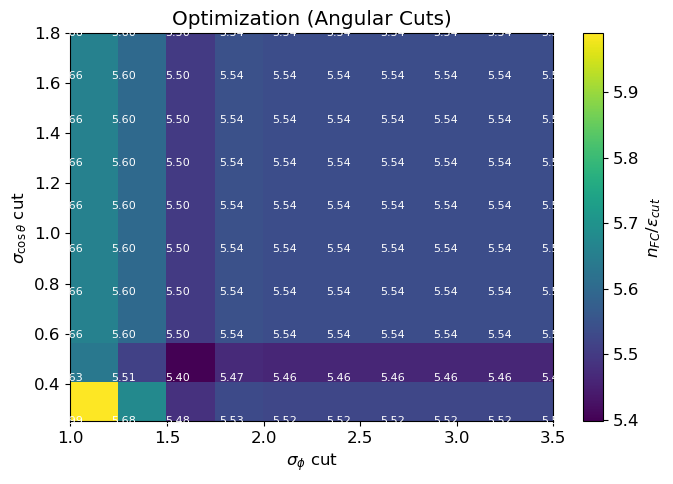

In [9]:
best_energy = best_log["energy_max"]
best_multi = best_log["multi_upper"]

df_ang = df_plot[
    (df_plot["energy_max"] == best_energy) &
    (df_plot["multi_upper"] == best_multi)
]

pivot_ang = df_ang.pivot(
    index="cos_cut",
    columns="phi_cut",
    values="score"
)

plt.figure(figsize=(7,5))

plt.imshow(
    pivot_ang,
    origin="lower",
    aspect="auto",
    extent=[
        pivot_ang.columns.min(),
        pivot_ang.columns.max(),
        pivot_ang.index.min(),
        pivot_ang.index.max()
    ]
)

plt.colorbar(label=r"$n_{FC}/\epsilon_{cut}$")
plt.xlabel(r"$\sigma_\phi$ cut")
plt.ylabel(r"$\sigma_{\cos\theta}$ cut")
plt.title("Optimization (Angular Cuts)")

# ---- ADD NUMBERS ON EACH CELL ----
for i, cos_val in enumerate(pivot_ang.index):
    for j, phi_val in enumerate(pivot_ang.columns):
        score = pivot_ang.iloc[i, j]
        plt.text(
            phi_val,
            cos_val,
            f"{score:.2f}",
            ha="center",
            va="center",
            color="white",
            fontsize=8
        )

plt.tight_layout()
plt.show()

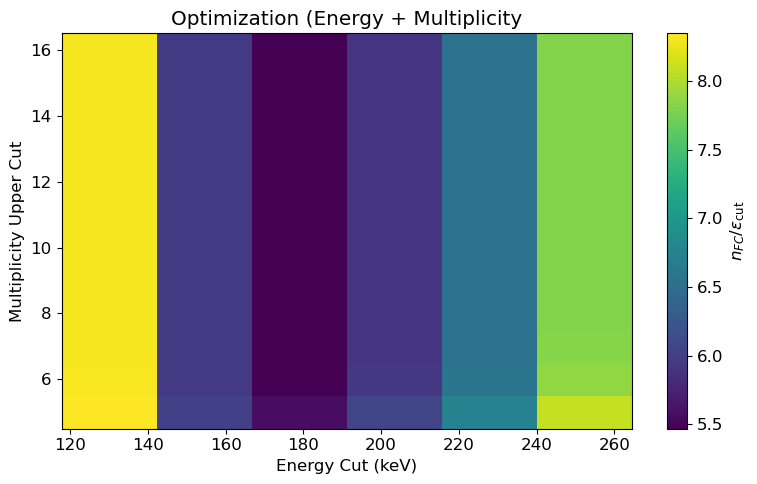

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Select only the best angles (fixed φ and cosθ)
best_phi = 1.5
best_cos = 0.4

df_em = df_plot[
    (df_plot["phi_cut"] == best_phi) &
    (df_plot["cos_cut"] == best_cos)
]

# Pivot: rows = multi_upper, columns = energy_max, values = score
pivot_em = df_em.pivot(
    index="multi_upper",
    columns="energy_max",
    values="score"
)


pivot_em_clean = pivot_em.dropna(how='all').dropna(axis=1, how='all')


multi_vals = pivot_em_clean.index.values
energy_vals = pivot_em_clean.columns.values
X, Y = np.meshgrid(energy_vals, multi_vals)


plt.figure(figsize=(8,5))
plt.pcolormesh(X, Y, pivot_em_clean.values, shading='auto')
plt.colorbar(label=r"$n_{FC}/\epsilon_{\rm cut}$")
plt.xlabel("Energy Cut (keV)")
plt.ylabel("Multiplicity Upper Cut")
plt.title("Optimization (Energy + Multiplicity)")
plt.tight_layout()
plt.show()

Best cut under eff_bkg < bkg_max:
energy_max     178.888889
phi_cut          1.500000
cos_cut          0.400000
multi_upper      7.000000
eff_signal       0.618024
eff_bkg          0.000123
FoM             55.743913
mu_b             1.036512
fc_n             3.380081
logscore         1.699128
Name: 12, dtype: float64


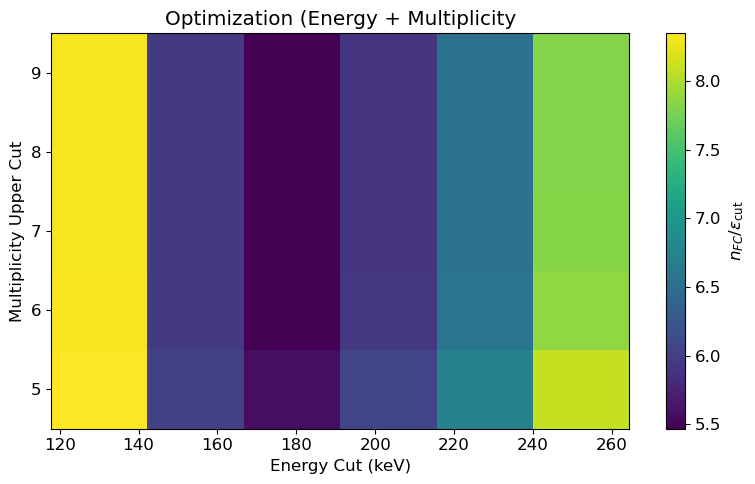

In [24]:
import numpy as np
import pandas as pd
from itertools import product
from scipy.interpolate import interp1d   


def prepare_fc_lookup(fc_x, fc_y):
    """
    Prepare an interpolator that returns fc_n for any (possibly non-integer) mu_b.
    fc_x: array-like of mu_b points (expected background mean; typically integers 0,1,2,...)
    fc_y: array-like of corresponding Feldman-Cousins n values at those mu_b points
    Returns: function fc_interp(mu) -> n (float)
    """
    fc_x = np.asarray(fc_x)
    fc_y = np.asarray(fc_y)
    # sort just in case
    order = np.argsort(fc_x)
    fc_x = fc_x[order]
    fc_y = fc_y[order]
    # create linear interpolator with fill_value="extrapolate" (or you can clamp)
    interp = interp1d(fc_x, fc_y, kind='linear', bounds_error=False, fill_value=(fc_y[0], fc_y[-1]))
    return interp


def apply_all_cuts(df, std_devs, phi_cut, cos_cut, energy_max, multi_upper):
    """
    Applies all cuts (including variable multiplicity upper limit)
    and returns surviving fraction (efficiency).
    """
    df_trigger = df[df["multiplicity"] > 2]
    total = df_trigger["evtid"].nunique()

    #Multi cut
    df_mult = df_trigger[df_trigger["multiplicity"] < multi_upper]

    #Energy Cut
    summed = df_mult.groupby("evtid")["total_edep"].sum()
    passed_energy = summed[summed < energy_max]
    df_energy = df_mult[df_mult["evtid"].isin(passed_energy.index)]

    #Spatial Cuts
    std_cut = std_devs[std_devs["evtid"].isin(df_energy["evtid"])]
    spatial_passed = std_cut[
        (std_cut["weighted_std_dev_phi"] < phi_cut) &
        (std_cut["weighted_std_dev_cos_theta"] < cos_cut)
    ]

    df_final = df_energy[df_energy["evtid"].isin(spatial_passed["evtid"])]

    eff = df_final["evtid"].nunique() / total if total > 0 else 0.0
    return eff



energy_grid = np.linspace(130, 350 , 10)
phi_grid = [1.5]
cos_grid = [0.4]
multi_upper_grid = np.arange(5, 10, 1) 

results = []


fc_dict = {
    0: 2.44,
    1: 3.36,
    2: 3.91,
    3: 4.42,
    4: 4.6,
    5: 4.99,
    6: 5.47,
    7: 5.53,
    8: 5.99,
    9: 6.3,
    10: 6.5,
    11: 6.81,
    12: 7,
    13: 7.05,
    14: 7.5,
    15: 7.52 
    
}

fc_x = np.array(list(fc_dict.keys()), dtype=float)
fc_y = np.array(list(fc_dict.values()), dtype=float)
fc_interp = prepare_fc_lookup(fc_x, fc_y)


for energy_max, phi_cut, cos_cut, multi_upper in product(energy_grid, phi_grid, cos_grid, multi_upper_grid):
    eff_b = apply_all_cuts(df_summary_muon_P08[df_summary_muon_P08["multiplicity"] > 2], std_devs_muon, phi_cut, cos_cut, energy_max, multi_upper)
    eff_s = apply_all_cuts(df_summary_25_P08[df_summary_25_P08["multiplicity"] > 2], std_devs_25, phi_cut, cos_cut, energy_max, multi_upper)
    # compute FoM same as before (guard against zero background eff)
    fom = eff_s / np.sqrt(eff_b) if eff_b > 0 else 0.0

    # compute expected background mean mu_b from epsilon_bkg
    mu_b = eff_b * (2878.0 * 2.93)

    # get Feldman-Cousins n (interpolated)
    fc_n = float(fc_interp(mu_b))

    results.append({
        "energy_max": energy_max,
        "phi_cut": phi_cut,
        "cos_cut": cos_cut,
        "multi_upper": multi_upper,
        "eff_signal": eff_s,
        "eff_bkg": eff_b,
        "FoM": fom,
        "mu_b": mu_b,
        "fc_n": fc_n
    })


df_fom = pd.DataFrame(results)

bkg_max = 15 / (2878.0 * 2.93)   # 0.00521

# apply background constraint
valid = df_fom[df_fom["eff_bkg"] < bkg_max].copy()

if valid.empty:
    print(f"No cut combination satisfies eff_bkg < {bkg_max}")
else:
    # scoring: minimize Feldman-Cousins n / signal efficiency
    valid["score"] = valid["fc_n"] / (valid["eff_signal"])
    valid["logscore"] = np.log(valid["fc_n"]) - np.log(valid["eff_signal"])

    best_log = valid.loc[valid["logscore"].idxmin()]

    print("Best cut under eff_bkg < bkg_max:")
    print(best_log[[
        "energy_max","phi_cut","cos_cut","multi_upper",
        "eff_signal","eff_bkg","FoM","mu_b","fc_n","logscore"
    ]])


df_plot = df_fom[df_fom["eff_bkg"] < bkg_max].copy()
df_plot["score"] = df_plot["fc_n"] / (df_plot["eff_signal"] + 1e-12)  # compute score


best_phi = 1.5
best_cos = 0.4

df_em = df_plot[
    (df_plot["phi_cut"] == best_phi) &
    (df_plot["cos_cut"] == best_cos)
]


pivot_em = df_em.pivot(
    index="multi_upper",
    columns="energy_max",
    values="score"
)


pivot_em_clean = pivot_em.dropna(how='all').dropna(axis=1, how='all')


multi_vals = pivot_em_clean.index.values
energy_vals = pivot_em_clean.columns.values
X, Y = np.meshgrid(energy_vals, multi_vals)

# Plot
plt.figure(figsize=(8,5))
plt.pcolormesh(X, Y, pivot_em_clean.values, shading='auto')
plt.colorbar(label=r"$n_{FC}/\epsilon_{\rm cut}$")
plt.xlabel("Energy Cut (keV)")
plt.ylabel("Multiplicity Upper Cut")
plt.title("Optimization (Energy + Multiplicity")
plt.tight_layout()
plt.show()

best_phi = best_log["phi_cut"]
best_multi = best_log["multi_upper"]

df_em = df_plot[
    (df_plot["phi_cut"] == best_phi) &
    (df_plot["multi_upper"] == best_multi)
]

pivot_em = df_em.pivot(
    index="cos_cut",
    columns="energy_max",
    values="score"
)

plt.figure(figsize=(7,5))

plt.imshow(
    pivot_em,
    origin="lower",
    aspect="auto",
    extent=[
        pivot_em.columns.min(),
        pivot_em.columns.max(),
        pivot_em.index.min(),
        pivot_em.index.max()
    ]
)

plt.colorbar(label=r"$n_{FC}/\epsilon_{cut}$")
plt.xlabel("Energy Cut (keV)")
plt.ylabel("Multiplicity Upper Cut")
plt.title("Optimization")
plt.tight_layout()
plt.show()